In \[1\]:

    #Importing Libraries
    import pandas as pd
    import numpy as np

    import matplotlib.pyplot as plt
    import seaborn as sns

    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler

    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline

    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import OneHotEncoder

    from sklearn.linear_model import LinearRegression

    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In \[3\]:

    #Loading Dataset
    df = pd.read_csv(r"C:\Users\Megha I Angadi\Downloads\manufacturing_dataset_1000_samples.csv")
    df.head()

Out\[3\]:

|     | Timestamp           | Injection_Temperature | Injection_Pressure | Cycle_Time | Cooling_Time | Material_Viscosity | Ambient_Temperature | Machine_Age | Operator_Experience | Maintenance_Hours | Shift   | Machine_Type | Material_Grade | Day_of_Week | Temperature_Pressure_Ratio | Total_Cycle_Time | Efficiency_Score | Machine_Utilization | Parts_Per_Hour |
|-----|---------------------|-----------------------|--------------------|------------|--------------|--------------------|---------------------|-------------|---------------------|-------------------|---------|--------------|----------------|-------------|----------------------------|------------------|------------------|---------------------|----------------|
| 0   | 2023-01-01 00:00:00 | 221.0                 | 136.0              | 28.7       | 13.6         | 375.5              | 28.0                | 3.8         | 11.2                | 64                | Evening | Type_B       | Economy        | Thursday    | 1.625                      | 42.3             | 0.063            | 0.510               | 36.5           |
| 1   | 2023-01-01 01:00:00 | 213.3                 | 128.9              | 34.5       | 14.0         | 215.8              | 22.6                | 6.8         | 6.3                 | 58                | Night   | Type_A       | Standard       | Wednesday   | 1.655                      | 48.5             | 0.037            | 0.389               | 29.9           |
| 2   | 2023-01-01 02:00:00 | 222.8                 | 115.9              | 19.9       | 9.5          | 307.0              | 25.3                | 4.2         | 9.6                 | 47                | Day     | Type_A       | Standard       | Monday      | 1.922                      | 29.4             | 0.061            | 0.551               | 56.9           |
| 3   | 2023-01-01 03:00:00 | 233.3                 | 105.3              | 39.2       | 13.1         | 137.8              | 26.0                | 9.2         | 8.6                 | 49                | Evening | Type_A       | Premium        | Saturday    | 2.215                      | 52.3             | 0.054            | 0.293               | 31.0           |
| 4   | 2023-01-01 04:00:00 | 212.2                 | 125.5              | 45.0       | 9.9          | 298.2              | 23.6                | 6.2         | 23.0                | 49                | Night   | Type_B       | Premium        | Monday      | 1.691                      | 54.9             | 0.145            | 0.443               | 15.0           |

In \[4\]:

    print("\nDataset Shape")
    df.shape

    print("\nDataset Information")
    df.info()

    print("\nMissing Values")
    df.isnull().sum()

    Dataset Shape

    Dataset Information
    <class 'pandas.core.frame.DataFrame'>
    RangeIndex: 1000 entries, 0 to 999
    Data columns (total 19 columns):
     #   Column                      Non-Null Count  Dtype  
    ---  ------                      --------------  -----  
     0   Timestamp                   1000 non-null   object 
     1   Injection_Temperature       1000 non-null   float64
     2   Injection_Pressure          1000 non-null   float64
     3   Cycle_Time                  1000 non-null   float64
     4   Cooling_Time                1000 non-null   float64
     5   Material_Viscosity          980 non-null    float64
     6   Ambient_Temperature         980 non-null    float64
     7   Machine_Age                 1000 non-null   float64
     8   Operator_Experience         980 non-null    float64
     9   Maintenance_Hours           1000 non-null   int64  
     10  Shift                       1000 non-null   object 
     11  Machine_Type                1000 non-null   object 
     12  Material_Grade              1000 non-null   object 
     13  Day_of_Week                 1000 non-null   object 
     14  Temperature_Pressure_Ratio  1000 non-null   float64
     15  Total_Cycle_Time            1000 non-null   float64
     16  Efficiency_Score            1000 non-null   float64
     17  Machine_Utilization         1000 non-null   float64
     18  Parts_Per_Hour              1000 non-null   float64
    dtypes: float64(13), int64(1), object(5)
    memory usage: 148.6+ KB

    Missing Values

Out\[4\]:

    Timestamp                      0
    Injection_Temperature          0
    Injection_Pressure             0
    Cycle_Time                     0
    Cooling_Time                   0
    Material_Viscosity            20
    Ambient_Temperature           20
    Machine_Age                    0
    Operator_Experience           20
    Maintenance_Hours              0
    Shift                          0
    Machine_Type                   0
    Material_Grade                 0
    Day_of_Week                    0
    Temperature_Pressure_Ratio     0
    Total_Cycle_Time               0
    Efficiency_Score               0
    Machine_Utilization            0
    Parts_Per_Hour                 0
    dtype: int64

In \[5\]:

    # Drop Timestamp Column
    if 'Timestamp' in df.columns:
        df.drop('Timestamp', axis=1, inplace=True)

In \[6\]:

    #Exploratory Data Analysis
    print("\nStatistical Summary")
    print(df.describe())

    Statistical Summary
           Injection_Temperature  Injection_Pressure  Cycle_Time  Cooling_Time  \
    count            1000.000000         1000.000000  1000.00000    1000.00000   
    mean              215.315900          116.075000    35.85170      11.92320   
    std                11.995507           14.667246     8.35349       2.30429   
    min               180.000000           80.000000    16.30000       8.00000   
    25%               207.200000          105.900000    28.80000      10.27500   
    50%               215.300000          115.950000    36.85000      11.90000   
    75%               222.800000          125.925000    45.00000      13.50000   
    max               300.000000          150.000000    60.00000      19.90000   

           Material_Viscosity  Ambient_Temperature  Machine_Age  \
    count          980.000000           980.000000  1000.000000   
    mean           251.630714            22.941224     7.855900   
    std             73.348695             2.773712     3.900798   
    min            104.600000            18.000000     1.000000   
    25%            200.900000            20.800000     4.700000   
    50%            242.700000            22.900000     7.900000   
    75%            295.300000            25.100000    11.100000   
    max           1000.000000            28.000000    15.000000   

           Operator_Experience  Maintenance_Hours  Temperature_Pressure_Ratio  \
    count           980.000000        1000.000000                 1000.000000   
    mean             30.795204          50.580000                    1.885852   
    std              27.684769          16.014558                    0.274323   
    min               1.000000          26.000000                    1.286000   
    25%               9.800000          45.000000                    1.683750   
    50%              22.100000          50.000000                    1.849500   
    75%              43.425000          55.000000                    2.044250   
    max             120.000000         500.000000                    2.843000   

           Total_Cycle_Time  Efficiency_Score  Machine_Utilization  Parts_Per_Hour  
    count       1000.000000       1000.000000          1000.000000     1000.000000  
    mean          47.737000          0.192688             0.356844       29.298100  
    std            8.671153          0.173839             0.195610       11.955497  
    min           24.600000          0.006000             0.001000        5.000000  
    25%           41.000000          0.061000             0.193000       17.500000  
    50%           48.550000          0.139000             0.355500       28.200000  
    75%           55.300000          0.274000             0.520000       38.000000  
    max           64.900000          0.840000             0.755000       68.600000  

In \[7\]:

    plt.figure(figsize=(10,8))
    sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
    plt.title("Correlation Heatmap")
    plt.show()

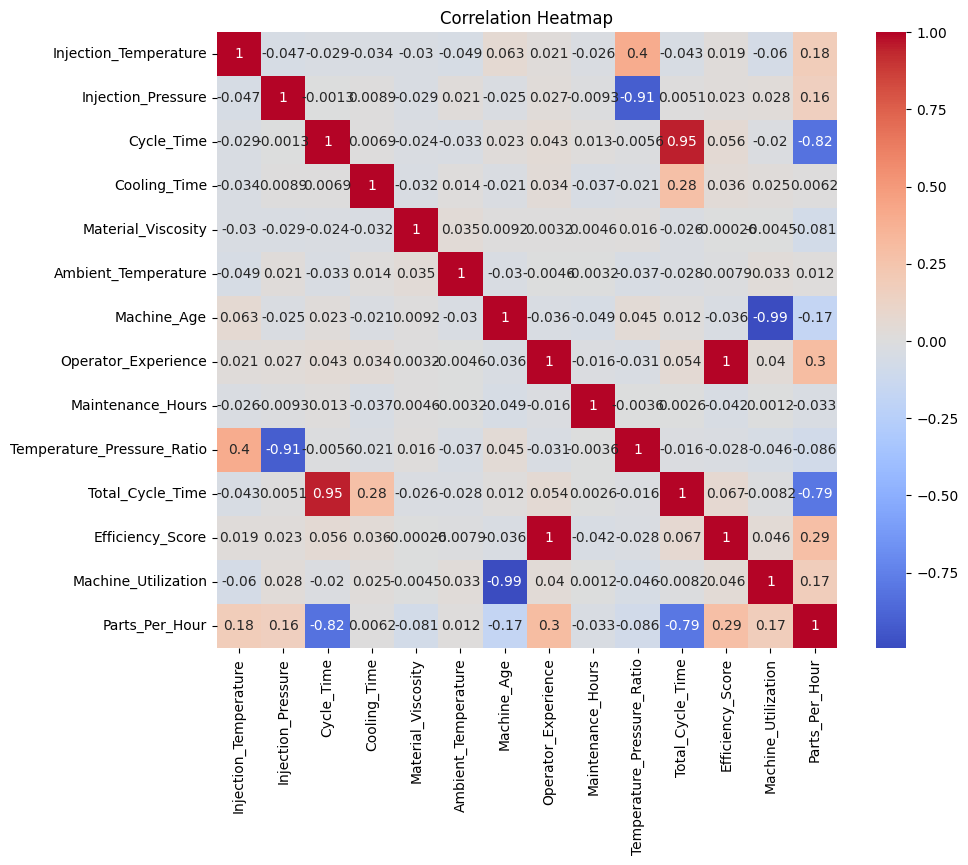

In \[8\]:

    # Distribution of Target Variable
    plt.figure(figsize=(8,5))
    sns.histplot(df["Parts_Per_Hour"], bins=30, kde=True)
    plt.title("Distribution of Parts Per Hour")
    plt.show()

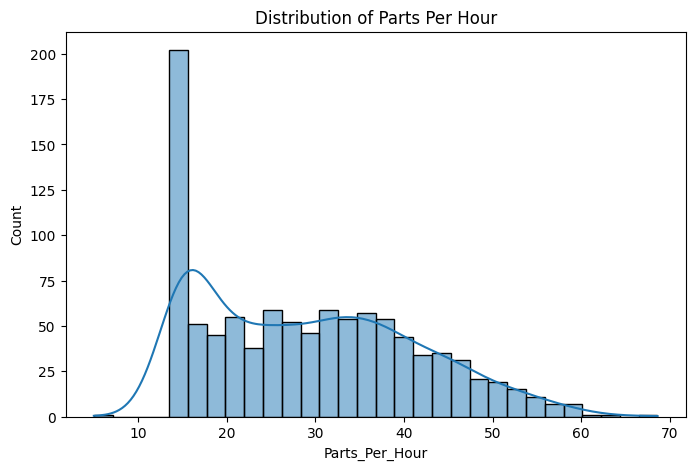

In \[9\]:

    #Separate Features and Target
    X = df.drop("Parts_Per_Hour", axis=1)
    y = df["Parts_Per_Hour"]

In \[10\]:

    #Identify Numerical and Categorical Columns
    numerical_cols = X.select_dtypes(include=['int64','float64']).columns

    categorical_cols = X.select_dtypes(include=['object']).columns

    print("Numerical Columns:")
    print(numerical_cols)

    print("\nCategorical Columns:")
    print(categorical_cols)

    Numerical Columns:
    Index(['Injection_Temperature', 'Injection_Pressure', 'Cycle_Time',
           'Cooling_Time', 'Material_Viscosity', 'Ambient_Temperature',
           'Machine_Age', 'Operator_Experience', 'Maintenance_Hours',
           'Temperature_Pressure_Ratio', 'Total_Cycle_Time', 'Efficiency_Score',
           'Machine_Utilization'],
          dtype='object')

    Categorical Columns:
    Index(['Shift', 'Machine_Type', 'Material_Grade', 'Day_of_Week'], dtype='object')

In \[11\]:

    #Preprocessing
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numerical_cols),
            ("cat", categorical_transformer, categorical_cols)
        ]
    )

In \[12\]:

    #Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

In \[13\]:

    #Build Pipeline
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ])

In \[14\]:

    #Train Model
    model.fit(X_train, y_train)

Out\[14\]:

    Pipeline(steps=[('preprocessor',
                     ColumnTransformer(transformers=[('num',
                                                      Pipeline(steps=[('imputer',
                                                                       SimpleImputer()),
                                                                      ('scaler',
                                                                       StandardScaler())]),
                                                      Index(['Injection_Temperature', 'Injection_Pressure', 'Cycle_Time',
           'Cooling_Time', 'Material_Viscosity', 'Ambient_Temperature',
           'Machine_Age', 'Operator_Experience', 'Maintenance_Hours',
           'Temperature_Pressure_Ratio', 'Total_Cycle_Time', 'Efficiency_Score',
           'Machine_Utilization'],
          dtype='object')),
                                                     ('cat',
                                                      Pipeline(steps=[('imputer',
                                                                       SimpleImputer(strategy='most_frequent')),
                                                                      ('encoder',
                                                                       OneHotEncoder(handle_unknown='ignore'))]),
                                                      Index(['Shift', 'Machine_Type', 'Material_Grade', 'Day_of_Week'], dtype='object'))])),
                    ('regressor', LinearRegression())])

**In a Jupyter environment, please rerun this cell to show the HTML
representation or trust the notebook.  
On GitHub, the HTML representation is unable to render, please try
loading this page with nbviewer.org.**

Pipeline

<a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.pipeline.Pipeline.html"
class="sk-estimator-doc-link fitted" rel="noreferrer"
target="_blank">?<span>Documentation for Pipeline</span></a><span
class="sk-estimator-doc-link fitted">iFitted</span>

Parameters

<table class="parameters-table">
<colgroup>
<col style="width: 33%" />
<col style="width: 33%" />
<col style="width: 33%" />
</colgroup>
<tbody>
<tr class="odd user-set">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.pipeline.Pipeline.html#:~:text=steps,-list%20of%20tuples"
class="param-doc-link" rel="noreferrer" target="_blank">steps <span
class="param-doc-description">steps: list of tuples<br />
<br />
List of (name of step, estimator) tuples that are to be chained in<br />
sequential order. To be compatible with the scikit-learn API, all
steps<br />
must define `fit`. All non-last steps must also define `transform`.
See<br />
:ref:`Combining Estimators ` for more details.</span></a></td>
<td class="value">[('preprocessor', ...), ('regressor', ...)]</td>
</tr>
<tr class="even default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.pipeline.Pipeline.html#:~:text=transform_input,-list%20of%20str%2C%20default%3DNone"
class="param-doc-link" rel="noreferrer" target="_blank">transform_input
<span class="param-doc-description">transform_input: list of str,
default=None<br />
<br />
The names of the :term:`metadata` parameters that should be transformed
by the<br />
pipeline before passing it to the step consuming it.<br />
<br />
This enables transforming some input arguments to ``fit`` (other than
``X``)<br />
to be transformed by the steps of the pipeline up to the step which
requires<br />
them. Requirement is defined via :ref:`metadata routing `.<br />
For instance, this can be used to pass a validation set through the
pipeline.<br />
<br />
You can only set this if metadata routing is enabled, which you<br />
can enable using
``sklearn.set_config(enable_metadata_routing=True)``.<br />
<br />
.. versionadded:: 1.6</span></a></td>
<td class="value">None</td>
</tr>
<tr class="odd default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.pipeline.Pipeline.html#:~:text=memory,-str%20or%20object%20with%20the%20joblib.Memory%20interface%2C%20default%3DNone"
class="param-doc-link" rel="noreferrer" target="_blank">memory <span
class="param-doc-description">memory: str or object with the
joblib.Memory interface, default=None<br />
<br />
Used to cache the fitted transformers of the pipeline. The last
step<br />
will never be cached, even if it is a transformer. By default, no<br />
caching is performed. If a string is given, it is the path to the<br />
caching directory. Enabling caching triggers a clone of the
transformers<br />
before fitting. Therefore, the transformer instance given to the<br />
pipeline cannot be inspected directly. Use the attribute
``named_steps``<br />
or ``steps`` to inspect estimators within the pipeline. Caching
the<br />
transformers is advantageous when fitting is time consuming. See<br />
:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`<br />
for an example on how to enable caching.</span></a></td>
<td class="value">None</td>
</tr>
<tr class="even default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.pipeline.Pipeline.html#:~:text=verbose,-bool%2C%20default%3DFalse"
class="param-doc-link" rel="noreferrer" target="_blank">verbose <span
class="param-doc-description">verbose: bool, default=False<br />
<br />
If True, the time elapsed while fitting each step will be printed as
it<br />
is completed.</span></a></td>
<td class="value">False</td>
</tr>
</tbody>
</table>

preprocessor: ColumnTransformer

<a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.compose.ColumnTransformer.html"
class="sk-estimator-doc-link fitted" rel="noreferrer"
target="_blank">?<span>Documentation for preprocessor:
ColumnTransformer</span></a>

Parameters

<table class="parameters-table">
<colgroup>
<col style="width: 33%" />
<col style="width: 33%" />
<col style="width: 33%" />
</colgroup>
<tbody>
<tr class="odd user-set">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.compose.ColumnTransformer.html#:~:text=transformers,-list%20of%20tuples"
class="param-doc-link" rel="noreferrer" target="_blank">transformers
<span class="param-doc-description">transformers: list of tuples<br />
<br />
List of (name, transformer, columns) tuples specifying the<br />
transformer objects to be applied to subsets of the data.<br />
<br />
name : str<br />
Like in Pipeline and FeatureUnion, this allows the transformer and<br />
its parameters to be set using ``set_params`` and searched in grid<br />
search.<br />
transformer : {'drop', 'passthrough'} or estimator<br />
Estimator must support :term:`fit` and :term:`transform`.<br />
Special-cased strings 'drop' and 'passthrough' are accepted as<br />
well, to indicate to drop the columns or to pass them through<br />
untransformed, respectively.<br />
columns : str, array-like of str, int, array-like of int, array-like of
bool, slice or callable<br />
Indexes the data on its second axis. Integers are interpreted as<br />
positional columns, while strings can reference DataFrame columns<br />
by name. A scalar string or int should be used where<br />
``transformer`` expects X to be a 1d array-like (vector),<br />
otherwise a 2d array will be passed to the transformer.<br />
A callable is passed the input data `X` and can return any of the<br />
above. To select multiple columns by name or dtype, you can use<br />
:obj:`make_column_selector`.</span></a></td>
<td class="value">[('num', ...), ('cat', ...)]</td>
</tr>
<tr class="even default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.compose.ColumnTransformer.html#:~:text=remainder,-%7B%27drop%27%2C%20%27passthrough%27%7D%20or%20estimator%2C%20default%3D%27drop%27"
class="param-doc-link" rel="noreferrer" target="_blank">remainder <span
class="param-doc-description">remainder: {'drop', 'passthrough'} or
estimator, default='drop'<br />
<br />
By default, only the specified columns in `transformers` are<br />
transformed and combined in the output, and the non-specified<br />
columns are dropped. (default of ``'drop'``).<br />
By specifying ``remainder='passthrough'``, all remaining columns
that<br />
were not specified in `transformers`, but present in the data
passed<br />
to `fit` will be automatically passed through. This subset of
columns<br />
is concatenated with the output of the transformers. For
dataframes,<br />
extra columns not seen during `fit` will be excluded from the
output<br />
of `transform`.<br />
By setting ``remainder`` to be an estimator, the remaining<br />
non-specified columns will use the ``remainder`` estimator. The<br />
estimator must support :term:`fit` and :term:`transform`.<br />
Note that using this feature requires that the DataFrame columns<br />
input at :term:`fit` and :term:`transform` have identical
order.</span></a></td>
<td class="value">'drop'</td>
</tr>
<tr class="odd default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.compose.ColumnTransformer.html#:~:text=sparse_threshold,-float%2C%20default%3D0.3"
class="param-doc-link" rel="noreferrer" target="_blank">sparse_threshold
<span class="param-doc-description">sparse_threshold: float,
default=0.3<br />
<br />
If the output of the different transformers contains sparse
matrices,<br />
these will be stacked as a sparse matrix if the overall density is<br />
lower than this value. Use ``sparse_threshold=0`` to always return<br />
dense. When the transformed output consists of all dense data, the<br />
stacked result will be dense, and this keyword will be
ignored.</span></a></td>
<td class="value">0.3</td>
</tr>
<tr class="even default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.compose.ColumnTransformer.html#:~:text=n_jobs,-int%2C%20default%3DNone"
class="param-doc-link" rel="noreferrer" target="_blank">n_jobs <span
class="param-doc-description">n_jobs: int, default=None<br />
<br />
Number of jobs to run in parallel.<br />
``None`` means 1 unless in a :obj:`joblib.parallel_backend`
context.<br />
``-1`` means using all processors. See :term:`Glossary `<br />
for more details.</span></a></td>
<td class="value">None</td>
</tr>
<tr class="odd default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.compose.ColumnTransformer.html#:~:text=transformer_weights,-dict%2C%20default%3DNone"
class="param-doc-link" rel="noreferrer"
target="_blank">transformer_weights <span
class="param-doc-description">transformer_weights: dict,
default=None<br />
<br />
Multiplicative weights for features per transformer. The output of
the<br />
transformer is multiplied by these weights. Keys are transformer
names,<br />
values the weights.</span></a></td>
<td class="value">None</td>
</tr>
<tr class="even default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.compose.ColumnTransformer.html#:~:text=verbose,-bool%2C%20default%3DFalse"
class="param-doc-link" rel="noreferrer" target="_blank">verbose <span
class="param-doc-description">verbose: bool, default=False<br />
<br />
If True, the time elapsed while fitting each transformer will be<br />
printed as it is completed.</span></a></td>
<td class="value">False</td>
</tr>
<tr class="odd default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.compose.ColumnTransformer.html#:~:text=verbose_feature_names_out,-bool%2C%20str%20or%20Callable%5B%5Bstr%2C%20str%5D%2C%20str%5D%2C%20default%3DTrue"
class="param-doc-link" rel="noreferrer"
target="_blank">verbose_feature_names_out <span
class="param-doc-description">verbose_feature_names_out: bool, str or
Callable[[str, str], str], default=True<br />
<br />
- If True, :meth:`ColumnTransformer.get_feature_names_out` will
prefix<br />
all feature names with the name of the transformer that generated
that<br />
feature. It is equivalent to setting<br />
`verbose_feature_names_out="{transformer_name}__{feature_name}"`.<br />
- If False, :meth:`ColumnTransformer.get_feature_names_out` will
not<br />
prefix any feature names and will error if feature names are not<br />
unique.<br />
- If ``Callable[[str, str], str]``,<br />
:meth:`ColumnTransformer.get_feature_names_out` will rename all the
features<br />
using the name of the transformer. The first argument of the callable is
the<br />
transformer name and the second argument is the feature name. The
returned<br />
string will be the new feature name.<br />
- If ``str``, it must be a string ready for formatting. The given string
will<br />
be formatted using two field names: ``transformer_name`` and
``feature_name``.<br />
e.g. ``"{feature_name}__{transformer_name}"``. See :meth:`str.format`
method<br />
from the standard library for more info.<br />
<br />
.. versionadded:: 1.0<br />
<br />
.. versionchanged:: 1.6<br />
`verbose_feature_names_out` can be a callable or a string to be
formatted.</span></a></td>
<td class="value">True</td>
</tr>
<tr class="even default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.compose.ColumnTransformer.html#:~:text=force_int_remainder_cols,-bool%2C%20default%3DFalse"
class="param-doc-link" rel="noreferrer"
target="_blank">force_int_remainder_cols <span
class="param-doc-description">force_int_remainder_cols: bool,
default=False<br />
<br />
This parameter has no effect.<br />
<br />
.. note::<br />
If you do not access the list of columns for the remainder columns<br />
in the `transformers_` fitted attribute, you do not need to set<br />
this parameter.<br />
<br />
.. versionadded:: 1.5<br />
<br />
.. versionchanged:: 1.7<br />
The default value for `force_int_remainder_cols` will change from<br />
`True` to `False` in version 1.7.<br />
<br />
.. deprecated:: 1.7<br />
`force_int_remainder_cols` is deprecated and will be removed in
1.9.</span></a></td>
<td class="value">'deprecated'</td>
</tr>
</tbody>
</table>

num

    Index(['Injection_Temperature', 'Injection_Pressure', 'Cycle_Time',
           'Cooling_Time', 'Material_Viscosity', 'Ambient_Temperature',
           'Machine_Age', 'Operator_Experience', 'Maintenance_Hours',
           'Temperature_Pressure_Ratio', 'Total_Cycle_Time', 'Efficiency_Score',
           'Machine_Utilization'],
          dtype='object')

SimpleImputer

<a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.impute.SimpleImputer.html"
class="sk-estimator-doc-link fitted" rel="noreferrer"
target="_blank">?<span>Documentation for SimpleImputer</span></a>

Parameters

<table class="parameters-table">
<colgroup>
<col style="width: 33%" />
<col style="width: 33%" />
<col style="width: 33%" />
</colgroup>
<tbody>
<tr class="odd default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.impute.SimpleImputer.html#:~:text=missing_values,-int%2C%20float%2C%20str%2C%20np.nan%2C%20None%20or%20pandas.NA%2C%20default%3Dnp.nan"
class="param-doc-link" rel="noreferrer" target="_blank">missing_values
<span class="param-doc-description">missing_values: int, float, str,
np.nan, None or pandas.NA, default=np.nan<br />
<br />
The placeholder for the missing values. All occurrences of<br />
`missing_values` will be imputed. For pandas' dataframes with<br />
nullable integer dtypes with missing values, `missing_values`<br />
can be set to either `np.nan` or `pd.NA`.</span></a></td>
<td class="value">nan</td>
</tr>
<tr class="even default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.impute.SimpleImputer.html#:~:text=strategy,-str%20or%20Callable%2C%20default%3D%27mean%27"
class="param-doc-link" rel="noreferrer" target="_blank">strategy <span
class="param-doc-description">strategy: str or Callable,
default='mean'<br />
<br />
The imputation strategy.<br />
<br />
- If "mean", then replace missing values using the mean along<br />
each column. Can only be used with numeric data.<br />
- If "median", then replace missing values using the median along<br />
each column. Can only be used with numeric data.<br />
- If "most_frequent", then replace missing using the most frequent<br />
value along each column. Can be used with strings or numeric data.<br />
If there is more than one such value, only the smallest is
returned.<br />
- If "constant", then replace missing values with fill_value. Can
be<br />
used with strings or numeric data.<br />
- If an instance of Callable, then replace missing values using
the<br />
scalar statistic returned by running the callable over a dense 1d<br />
array containing non-missing values of each column.<br />
<br />
.. versionadded:: 0.20<br />
strategy="constant" for fixed value imputation.<br />
<br />
.. versionadded:: 1.5<br />
strategy=callable for custom value imputation.</span></a></td>
<td class="value">'mean'</td>
</tr>
<tr class="odd default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.impute.SimpleImputer.html#:~:text=fill_value,-str%20or%20numerical%20value%2C%20default%3DNone"
class="param-doc-link" rel="noreferrer" target="_blank">fill_value <span
class="param-doc-description">fill_value: str or numerical value,
default=None<br />
<br />
When strategy == "constant", `fill_value` is used to replace all<br />
occurrences of missing_values. For string or object data types,<br />
`fill_value` must be a string.<br />
If `None`, `fill_value` will be 0 when imputing numerical<br />
data and "missing_value" for strings or object data
types.</span></a></td>
<td class="value">None</td>
</tr>
<tr class="even default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.impute.SimpleImputer.html#:~:text=copy,-bool%2C%20default%3DTrue"
class="param-doc-link" rel="noreferrer" target="_blank">copy <span
class="param-doc-description">copy: bool, default=True<br />
<br />
If True, a copy of X will be created. If False, imputation will<br />
be done in-place whenever possible. Note that, in the following
cases,<br />
a new copy will always be made, even if `copy=False`:<br />
<br />
- If `X` is not an array of floating values;<br />
- If `X` is encoded as a CSR matrix;<br />
- If `add_indicator=True`.</span></a></td>
<td class="value">True</td>
</tr>
<tr class="odd default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.impute.SimpleImputer.html#:~:text=add_indicator,-bool%2C%20default%3DFalse"
class="param-doc-link" rel="noreferrer" target="_blank">add_indicator
<span class="param-doc-description">add_indicator: bool,
default=False<br />
<br />
If True, a :class:`MissingIndicator` transform will stack onto
output<br />
of the imputer's transform. This allows a predictive estimator<br />
to account for missingness despite imputation. If a feature has no<br />
missing values at fit/train time, the feature won't appear on<br />
the missing indicator even if there are missing values at<br />
transform/test time.</span></a></td>
<td class="value">False</td>
</tr>
<tr class="even default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.impute.SimpleImputer.html#:~:text=keep_empty_features,-bool%2C%20default%3DFalse"
class="param-doc-link" rel="noreferrer"
target="_blank">keep_empty_features <span
class="param-doc-description">keep_empty_features: bool,
default=False<br />
<br />
If True, features that consist exclusively of missing values when<br />
`fit` is called are returned in results when `transform` is
called.<br />
The imputed value is always `0` except when `strategy="constant"`<br />
in which case `fill_value` will be used instead.<br />
<br />
.. versionadded:: 1.2</span></a></td>
<td class="value">False</td>
</tr>
</tbody>
</table>

StandardScaler

<a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.preprocessing.StandardScaler.html"
class="sk-estimator-doc-link fitted" rel="noreferrer"
target="_blank">?<span>Documentation for StandardScaler</span></a>

Parameters

<table class="parameters-table">
<colgroup>
<col style="width: 33%" />
<col style="width: 33%" />
<col style="width: 33%" />
</colgroup>
<tbody>
<tr class="odd default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.preprocessing.StandardScaler.html#:~:text=copy,-bool%2C%20default%3DTrue"
class="param-doc-link" rel="noreferrer" target="_blank">copy <span
class="param-doc-description">copy: bool, default=True<br />
<br />
If False, try to avoid a copy and do inplace scaling instead.<br />
This is not guaranteed to always work inplace; e.g. if the data is<br />
not a NumPy array or scipy.sparse CSR matrix, a copy may still be<br />
returned.</span></a></td>
<td class="value">True</td>
</tr>
<tr class="even default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.preprocessing.StandardScaler.html#:~:text=with_mean,-bool%2C%20default%3DTrue"
class="param-doc-link" rel="noreferrer" target="_blank">with_mean <span
class="param-doc-description">with_mean: bool, default=True<br />
<br />
If True, center the data before scaling.<br />
This does not work (and will raise an exception) when attempted on<br />
sparse matrices, because centering them entails building a dense<br />
matrix which in common use cases is likely to be too large to fit
in<br />
memory.</span></a></td>
<td class="value">True</td>
</tr>
<tr class="odd default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.preprocessing.StandardScaler.html#:~:text=with_std,-bool%2C%20default%3DTrue"
class="param-doc-link" rel="noreferrer" target="_blank">with_std <span
class="param-doc-description">with_std: bool, default=True<br />
<br />
If True, scale the data to unit variance (or equivalently,<br />
unit standard deviation).</span></a></td>
<td class="value">True</td>
</tr>
</tbody>
</table>

cat

    Index(['Shift', 'Machine_Type', 'Material_Grade', 'Day_of_Week'], dtype='object')

SimpleImputer

<a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.impute.SimpleImputer.html"
class="sk-estimator-doc-link fitted" rel="noreferrer"
target="_blank">?<span>Documentation for SimpleImputer</span></a>

Parameters

<table class="parameters-table">
<colgroup>
<col style="width: 33%" />
<col style="width: 33%" />
<col style="width: 33%" />
</colgroup>
<tbody>
<tr class="odd default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.impute.SimpleImputer.html#:~:text=missing_values,-int%2C%20float%2C%20str%2C%20np.nan%2C%20None%20or%20pandas.NA%2C%20default%3Dnp.nan"
class="param-doc-link" rel="noreferrer" target="_blank">missing_values
<span class="param-doc-description">missing_values: int, float, str,
np.nan, None or pandas.NA, default=np.nan<br />
<br />
The placeholder for the missing values. All occurrences of<br />
`missing_values` will be imputed. For pandas' dataframes with<br />
nullable integer dtypes with missing values, `missing_values`<br />
can be set to either `np.nan` or `pd.NA`.</span></a></td>
<td class="value">nan</td>
</tr>
<tr class="even user-set">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.impute.SimpleImputer.html#:~:text=strategy,-str%20or%20Callable%2C%20default%3D%27mean%27"
class="param-doc-link" rel="noreferrer" target="_blank">strategy <span
class="param-doc-description">strategy: str or Callable,
default='mean'<br />
<br />
The imputation strategy.<br />
<br />
- If "mean", then replace missing values using the mean along<br />
each column. Can only be used with numeric data.<br />
- If "median", then replace missing values using the median along<br />
each column. Can only be used with numeric data.<br />
- If "most_frequent", then replace missing using the most frequent<br />
value along each column. Can be used with strings or numeric data.<br />
If there is more than one such value, only the smallest is
returned.<br />
- If "constant", then replace missing values with fill_value. Can
be<br />
used with strings or numeric data.<br />
- If an instance of Callable, then replace missing values using
the<br />
scalar statistic returned by running the callable over a dense 1d<br />
array containing non-missing values of each column.<br />
<br />
.. versionadded:: 0.20<br />
strategy="constant" for fixed value imputation.<br />
<br />
.. versionadded:: 1.5<br />
strategy=callable for custom value imputation.</span></a></td>
<td class="value">'most_frequent'</td>
</tr>
<tr class="odd default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.impute.SimpleImputer.html#:~:text=fill_value,-str%20or%20numerical%20value%2C%20default%3DNone"
class="param-doc-link" rel="noreferrer" target="_blank">fill_value <span
class="param-doc-description">fill_value: str or numerical value,
default=None<br />
<br />
When strategy == "constant", `fill_value` is used to replace all<br />
occurrences of missing_values. For string or object data types,<br />
`fill_value` must be a string.<br />
If `None`, `fill_value` will be 0 when imputing numerical<br />
data and "missing_value" for strings or object data
types.</span></a></td>
<td class="value">None</td>
</tr>
<tr class="even default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.impute.SimpleImputer.html#:~:text=copy,-bool%2C%20default%3DTrue"
class="param-doc-link" rel="noreferrer" target="_blank">copy <span
class="param-doc-description">copy: bool, default=True<br />
<br />
If True, a copy of X will be created. If False, imputation will<br />
be done in-place whenever possible. Note that, in the following
cases,<br />
a new copy will always be made, even if `copy=False`:<br />
<br />
- If `X` is not an array of floating values;<br />
- If `X` is encoded as a CSR matrix;<br />
- If `add_indicator=True`.</span></a></td>
<td class="value">True</td>
</tr>
<tr class="odd default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.impute.SimpleImputer.html#:~:text=add_indicator,-bool%2C%20default%3DFalse"
class="param-doc-link" rel="noreferrer" target="_blank">add_indicator
<span class="param-doc-description">add_indicator: bool,
default=False<br />
<br />
If True, a :class:`MissingIndicator` transform will stack onto
output<br />
of the imputer's transform. This allows a predictive estimator<br />
to account for missingness despite imputation. If a feature has no<br />
missing values at fit/train time, the feature won't appear on<br />
the missing indicator even if there are missing values at<br />
transform/test time.</span></a></td>
<td class="value">False</td>
</tr>
<tr class="even default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.impute.SimpleImputer.html#:~:text=keep_empty_features,-bool%2C%20default%3DFalse"
class="param-doc-link" rel="noreferrer"
target="_blank">keep_empty_features <span
class="param-doc-description">keep_empty_features: bool,
default=False<br />
<br />
If True, features that consist exclusively of missing values when<br />
`fit` is called are returned in results when `transform` is
called.<br />
The imputed value is always `0` except when `strategy="constant"`<br />
in which case `fill_value` will be used instead.<br />
<br />
.. versionadded:: 1.2</span></a></td>
<td class="value">False</td>
</tr>
</tbody>
</table>

OneHotEncoder

<a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.preprocessing.OneHotEncoder.html"
class="sk-estimator-doc-link fitted" rel="noreferrer"
target="_blank">?<span>Documentation for OneHotEncoder</span></a>

Parameters

<table class="parameters-table">
<colgroup>
<col style="width: 33%" />
<col style="width: 33%" />
<col style="width: 33%" />
</colgroup>
<tbody>
<tr class="odd default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.preprocessing.OneHotEncoder.html#:~:text=categories,-%27auto%27%20or%20a%20list%20of%20array-like%2C%20default%3D%27auto%27"
class="param-doc-link" rel="noreferrer" target="_blank">categories <span
class="param-doc-description">categories: 'auto' or a list of
array-like, default='auto'<br />
<br />
Categories (unique values) per feature:<br />
<br />
- 'auto' : Determine categories automatically from the training
data.<br />
- list : ``categories[i]`` holds the categories expected in the
ith<br />
column. The passed categories should not mix strings and numeric<br />
values within a single feature, and should be sorted in case of<br />
numeric values.<br />
<br />
The used categories can be found in the ``categories_`` attribute.<br />
<br />
.. versionadded:: 0.20</span></a></td>
<td class="value">'auto'</td>
</tr>
<tr class="even default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.preprocessing.OneHotEncoder.html#:~:text=drop,-%7B%27first%27%2C%20%27if_binary%27%7D%20or%20an%20array-like%20of%20shape%20%28n_features%2C%29%2C%20%20%20%20%20%20%20%20%20%20%20%20%20default%3DNone"
class="param-doc-link" rel="noreferrer" target="_blank">drop <span
class="param-doc-description">drop: {'first', 'if_binary'} or an
array-like of shape (n_features,), default=None<br />
<br />
Specifies a methodology to use to drop one of the categories per<br />
feature. This is useful in situations where perfectly collinear<br />
features cause problems, such as when feeding the resulting data<br />
into an unregularized linear regression model.<br />
<br />
However, dropping one category breaks the symmetry of the original<br />
representation and can therefore induce a bias in downstream
models,<br />
for instance for penalized linear classification or regression
models.<br />
<br />
- None : retain all features (the default).<br />
- 'first' : drop the first category in each feature. If only one<br />
category is present, the feature will be dropped entirely.<br />
- 'if_binary' : drop the first category in each feature with two<br />
categories. Features with 1 or more than 2 categories are<br />
left intact.<br />
- array : ``drop[i]`` is the category in feature ``X[:, i]`` that<br />
should be dropped.<br />
<br />
When `max_categories` or `min_frequency` is configured to group<br />
infrequent categories, the dropping behavior is handled after the<br />
grouping.<br />
<br />
.. versionadded:: 0.21<br />
The parameter `drop` was added in 0.21.<br />
<br />
.. versionchanged:: 0.23<br />
The option `drop='if_binary'` was added in 0.23.<br />
<br />
.. versionchanged:: 1.1<br />
Support for dropping infrequent categories.</span></a></td>
<td class="value">None</td>
</tr>
<tr class="odd default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.preprocessing.OneHotEncoder.html#:~:text=sparse_output,-bool%2C%20default%3DTrue"
class="param-doc-link" rel="noreferrer" target="_blank">sparse_output
<span class="param-doc-description">sparse_output: bool,
default=True<br />
<br />
When ``True``, it returns a :class:`scipy.sparse.csr_matrix`,<br />
i.e. a sparse matrix in "Compressed Sparse Row" (CSR) format.<br />
<br />
.. versionadded:: 1.2<br />
`sparse` was renamed to `sparse_output`</span></a></td>
<td class="value">True</td>
</tr>
<tr class="even default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.preprocessing.OneHotEncoder.html#:~:text=dtype,-number%20type%2C%20default%3Dnp.float64"
class="param-doc-link" rel="noreferrer" target="_blank">dtype <span
class="param-doc-description">dtype: number type,
default=np.float64<br />
<br />
Desired dtype of output.</span></a></td>
<td class="value">&lt;class 'numpy.float64'&gt;</td>
</tr>
<tr class="odd user-set">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.preprocessing.OneHotEncoder.html#:~:text=handle_unknown,-%7B%27error%27%2C%20%27ignore%27%2C%20%27infrequent_if_exist%27%2C%20%27warn%27%7D%2C%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20%20default%3D%27error%27"
class="param-doc-link" rel="noreferrer" target="_blank">handle_unknown
<span class="param-doc-description">handle_unknown: {'error', 'ignore',
'infrequent_if_exist', 'warn'}, default='error'<br />
<br />
Specifies the way unknown categories are handled during
:meth:`transform`.<br />
<br />
- 'error' : Raise an error if an unknown category is present during
transform.<br />
- 'ignore' : When an unknown category is encountered during<br />
transform, the resulting one-hot encoded columns for this feature<br />
will be all zeros. In the inverse transform, an unknown category<br />
will be denoted as None.<br />
- 'infrequent_if_exist' : When an unknown category is encountered<br />
during transform, the resulting one-hot encoded columns for this<br />
feature will map to the infrequent category if it exists. The<br />
infrequent category will be mapped to the last position in the<br />
encoding. During inverse transform, an unknown category will be<br />
mapped to the category denoted `'infrequent'` if it exists. If the<br />
`'infrequent'` category does not exist, then :meth:`transform` and<br />
:meth:`inverse_transform` will handle an unknown category as with<br />
`handle_unknown='ignore'`. Infrequent categories exist based on<br />
`min_frequency` and `max_categories`. Read more in the<br />
:ref:`User Guide `.<br />
- 'warn' : When an unknown category is encountered during
transform<br />
a warning is issued, and the encoding then proceeds as described
for<br />
`handle_unknown="infrequent_if_exist"`.<br />
<br />
.. versionchanged:: 1.1<br />
`'infrequent_if_exist'` was added to automatically handle unknown<br />
categories and infrequent categories.<br />
<br />
.. versionadded:: 1.6<br />
The option `"warn"` was added in 1.6.</span></a></td>
<td class="value">'ignore'</td>
</tr>
<tr class="even default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.preprocessing.OneHotEncoder.html#:~:text=min_frequency,-int%20or%20float%2C%20default%3DNone"
class="param-doc-link" rel="noreferrer" target="_blank">min_frequency
<span class="param-doc-description">min_frequency: int or float,
default=None<br />
<br />
Specifies the minimum frequency below which a category will be<br />
considered infrequent.<br />
<br />
- If `int`, categories with a smaller cardinality will be
considered<br />
infrequent.<br />
<br />
- If `float`, categories with a smaller cardinality than<br />
`min_frequency * n_samples` will be considered infrequent.<br />
<br />
.. versionadded:: 1.1<br />
Read more in the :ref:`User Guide `.</span></a></td>
<td class="value">None</td>
</tr>
<tr class="odd default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.preprocessing.OneHotEncoder.html#:~:text=max_categories,-int%2C%20default%3DNone"
class="param-doc-link" rel="noreferrer" target="_blank">max_categories
<span class="param-doc-description">max_categories: int,
default=None<br />
<br />
Specifies an upper limit to the number of output features for each
input<br />
feature when considering infrequent categories. If there are
infrequent<br />
categories, `max_categories` includes the category representing
the<br />
infrequent categories along with the frequent categories. If
`None`,<br />
there is no limit to the number of output features.<br />
<br />
.. versionadded:: 1.1<br />
Read more in the :ref:`User Guide `.</span></a></td>
<td class="value">None</td>
</tr>
<tr class="even default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.preprocessing.OneHotEncoder.html#:~:text=feature_name_combiner,-%22concat%22%20or%20callable%2C%20default%3D%22concat%22"
class="param-doc-link" rel="noreferrer"
target="_blank">feature_name_combiner <span
class="param-doc-description">feature_name_combiner: "concat" or
callable, default="concat"<br />
<br />
Callable with signature `def callable(input_feature, category)` that
returns a<br />
string. This is used to create feature names to be returned by<br />
:meth:`get_feature_names_out`.<br />
<br />
`"concat"` concatenates encoded feature name and category with<br />
`feature + "_" + str(category)`.E.g. feature X with values 1, 6, 7
create<br />
feature names `X_1, X_6, X_7`.<br />
<br />
.. versionadded:: 1.3</span></a></td>
<td class="value">'concat'</td>
</tr>
</tbody>
</table>

LinearRegression

<a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.linear_model.LinearRegression.html"
class="sk-estimator-doc-link fitted" rel="noreferrer"
target="_blank">?<span>Documentation for LinearRegression</span></a>

Parameters

<table class="parameters-table">
<colgroup>
<col style="width: 33%" />
<col style="width: 33%" />
<col style="width: 33%" />
</colgroup>
<tbody>
<tr class="odd default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.linear_model.LinearRegression.html#:~:text=fit_intercept,-bool%2C%20default%3DTrue"
class="param-doc-link" rel="noreferrer" target="_blank">fit_intercept
<span class="param-doc-description">fit_intercept: bool,
default=True<br />
<br />
Whether to calculate the intercept for this model. If set<br />
to False, no intercept will be used in calculations<br />
(i.e. data is expected to be centered).</span></a></td>
<td class="value">True</td>
</tr>
<tr class="even default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.linear_model.LinearRegression.html#:~:text=copy_X,-bool%2C%20default%3DTrue"
class="param-doc-link" rel="noreferrer" target="_blank">copy_X <span
class="param-doc-description">copy_X: bool, default=True<br />
<br />
If True, X will be copied; else, it may be overwritten.</span></a></td>
<td class="value">True</td>
</tr>
<tr class="odd default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.linear_model.LinearRegression.html#:~:text=tol,-float%2C%20default%3D1e-6"
class="param-doc-link" rel="noreferrer" target="_blank">tol <span
class="param-doc-description">tol: float, default=1e-6<br />
<br />
The precision of the solution (`coef_`) is determined by `tol`
which<br />
specifies a different convergence criterion for the `lsqr` solver.<br />
`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr`
when<br />
fitting on sparse training data. This parameter has no effect when
fitting<br />
on dense data.<br />
<br />
.. versionadded:: 1.7</span></a></td>
<td class="value">1e-06</td>
</tr>
<tr class="even default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.linear_model.LinearRegression.html#:~:text=n_jobs,-int%2C%20default%3DNone"
class="param-doc-link" rel="noreferrer" target="_blank">n_jobs <span
class="param-doc-description">n_jobs: int, default=None<br />
<br />
The number of jobs to use for the computation. This will only
provide<br />
speedup in case of sufficiently large problems, that is if firstly<br />
`n_targets &gt; 1` and secondly `X` is sparse or if `positive` is
set<br />
to `True`. ``None`` means 1 unless in a<br />
:obj:`joblib.parallel_backend` context. ``-1`` means using all<br />
processors. See :term:`Glossary ` for more details.</span></a></td>
<td class="value">None</td>
</tr>
<tr class="odd default">
<td><em></em></td>
<td class="param"><a
href="https://scikit-learn.org/1.8/modules/generated/sklearn.linear_model.LinearRegression.html#:~:text=positive,-bool%2C%20default%3DFalse"
class="param-doc-link" rel="noreferrer" target="_blank">positive <span
class="param-doc-description">positive: bool, default=False<br />
<br />
When set to ``True``, forces the coefficients to be positive. This<br />
option is only supported for dense arrays.<br />
<br />
For a comparison between a linear regression model with positive
constraints<br />
on the regression coefficients and a linear regression without such
constraints,<br />
see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`.<br />
<br />
.. versionadded:: 0.24</span></a></td>
<td class="value">False</td>
</tr>
</tbody>
</table>

In \[15\]:

    #Predictions
    y_pred = model.predict(X_test)

In \[16\]:

    #Evaluation
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\nModel Performance")
    print("-"*40)
    print("Mean Absolute Error :", mae)
    print("Mean Squared Error  :", mse)
    print("Root Mean Squared Error :", rmse)
    print("R2 Score :", r2)

    Model Performance
    ----------------------------------------
    Mean Absolute Error : 2.7157925856680856
    Mean Squared Error  : 12.281985844180927
    Root Mean Squared Error : 3.504566427417367
    R2 Score : 0.9058800089988768

In \[17\]:

    #Actual vs Predicted
    comparison = pd.DataFrame({
        "Actual": y_test,
        "Predicted": y_pred
    })

    print("\nActual vs Predicted")
    print(comparison.head(20))

    Actual vs Predicted
         Actual  Predicted
    521    18.6  19.905874
    737    42.8  44.403312
    740    34.2  34.060678
    660    40.0  39.709933
    411    15.0  18.387442
    678    15.0  20.438655
    626    33.6  33.532299
    513    15.0  14.118664
    859    25.0  27.971111
    136    24.2  32.332093
    811    25.7  23.964161
    76     34.4  25.948442
    636    17.2  19.548944
    973    17.0  21.848561
    938    23.0  24.033165
    899    35.4  36.602922
    280    15.0  17.865252
    883    15.0  16.713388
    761    18.8  19.690677
    319    15.0  14.464010

In \[18\]:

    #Scatter Plot
    plt.figure(figsize=(8,6))
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual Parts Per Hour")
    plt.ylabel("Predicted Parts Per Hour")
    plt.title("Actual vs Predicted")
    plt.show()

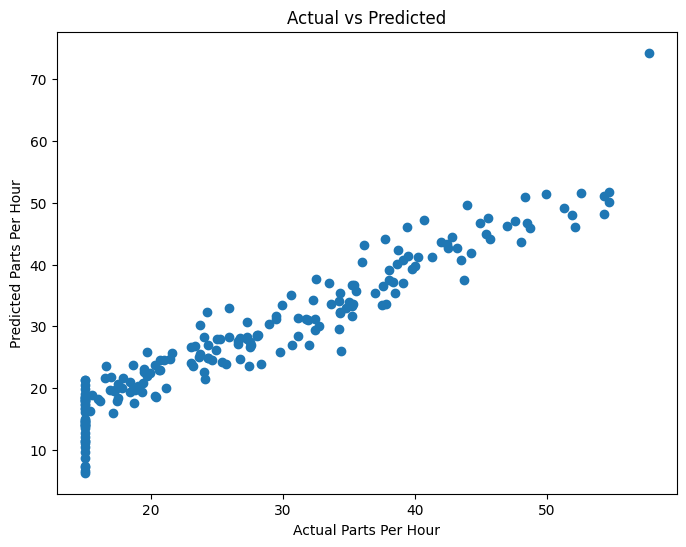

In \[19\]:

    #Residual Plot
    residuals = y_test - y_pred

    plt.figure(figsize=(8,6))
    sns.histplot(residuals, kde=True)
    plt.title("Residual Distribution")
    plt.xlabel("Residuals")
    plt.show()

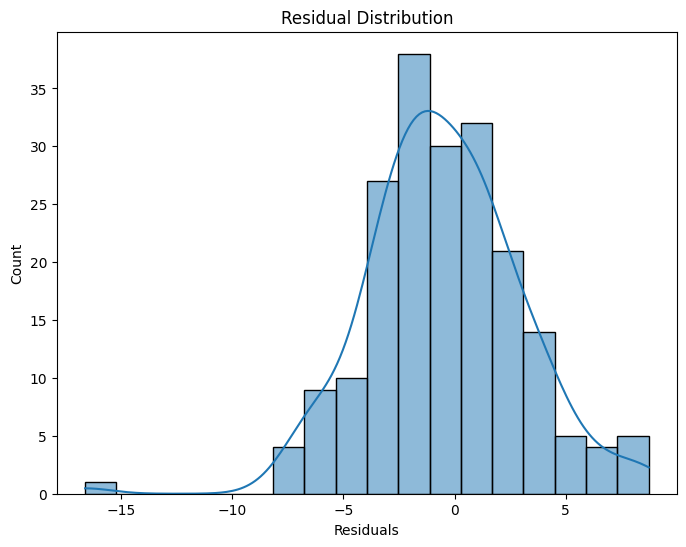

In \[20\]:

    #Save Predictions
    comparison.to_csv("predictions.csv", index=False)

    print("\nPrediction file saved successfully.")

    Prediction file saved successfully.

In \[ \]: